In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys
import torch

PROJECT_ROOT = "/content/drive/MyDrive/Explainable Detection of Online Sexism"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
os.environ["EDOS_CONFIG"] = "/content/drive/MyDrive/Explainable Detection of Online Sexism/config/config_v3.yaml"

from src.pipeline import setup, run_rnn_binary, run_rnn_category, run_transformer_binary, run_transformer_category
from config.config import (
    DATA_PATH, GLOVE_PATH, EMBED_DIM, MAX_VOCAB, MAX_LEN, HIDDEN_DIM, BATCH_SIZE, BATCH_SIZE_TRANSFORMER,
    MODEL_NAME, TRANSFORMER_MAX_LEN, EPOCHS, PATIENCE, USE_FOCAL, FOCAL_GAMMA, BINARY_LABELS, CATEGORY_LABELS,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
state = setup(device)

print(f"Data        : {DATA_PATH}")
print(f"GloVe       : {GLOVE_PATH}")
print(f"Embed dim   : {EMBED_DIM}")
print(f"Transformer : {MODEL_NAME}")
print(f"Epochs      : {EPOCHS}  |  Patience: {PATIENCE}")
print(f"Use Focal   : {USE_FOCAL}  |  gamma: {FOCAL_GAMMA}")

Mounted at /content/drive
Device: cuda
Loading data ...
Binary   — train: 16000  test: 4000
Category — train: 3884  test: 970

Building vocab + loading GloVe ...
Vocabulary size: 20000
GloVe coverage: 17294 / 20000 ( 86.5%)

Building RNN loaders ...
Building Transformer loaders ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Binary weights  : tensor([0.6603, 2.0597], device='cuda:0')
Category weights: tensor([2.7429, 0.5344, 0.7290, 2.5486], device='cuda:0')
Data        : /content/drive/MyDrive/Explainable Detection of Online Sexism/Dataset/edos_clean.csv
GloVe       : /content/drive/MyDrive/Explainable Detection of Online Sexism/GloVe/glove.twitter.27B.200d.txt
Embed dim   : 200
Transformer : roberta-base
Epochs      : 25  |  Patience: 6
Use Focal   : False  |  gamma: 2.0



BiLSTM — Task A (Binary)
Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      0.5843     0.7185    0.6804    0.8330    0.7787    LR: 1.00e-03


2      0.5080     0.8199    0.7819    0.8207    0.7711    LR: 1.00e-03


3      0.4312     0.8878    0.8587    0.8137    0.7647    LR: 1.00e-03


4      0.3593     0.9448    0.9275    0.8077    0.7554    LR: 5.00e-04


5      0.3083     0.9783    0.9709    0.8235    0.7603    LR: 5.00e-04


6      0.2926     0.9893    0.9855    0.8253    0.7628    LR: 5.00e-04


7      0.2850     0.9935    0.9912    0.8173    0.7563    LR: 2.50e-04

Early stopping triggered

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not sexist       0.89      0.87      0.88      3030
      Sexist       0.62      0.65      0.63       970

    accuracy                           0.82      4000
   macro avg       0.75      0.76      0.76      4000
weighted avg       0.82      0.82      0.82      4000

Accuracy : 0.8173
Macro F1 : 0.7563
Weighted F1 : 0.8190

Confusion Matrix (raw):
[[2635  395]
 [ 336  634]]


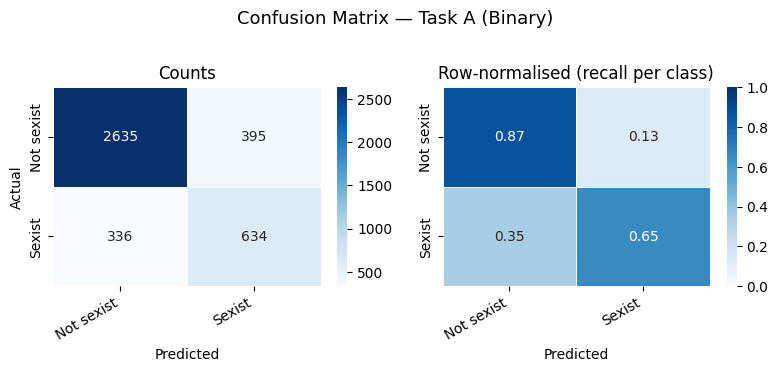

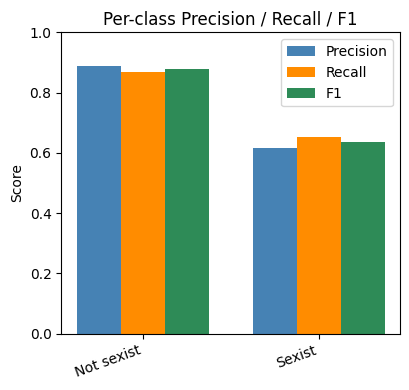


ERROR ANALYSIS

Total errors: 731 / 4000 (18.3%)

Error rate per true class:


,class,errors,total,error_rate (%)
1,Sexist,336,970,34.6
0,Not sexist,395,3030,13.0



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Not sexist,Sexist,395
1,Sexist,Not sexist,336


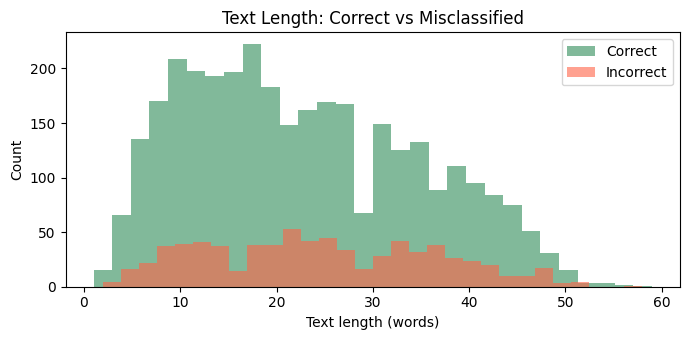


Sample misclassified examples:

  ✗ Actual: [Not sexist]  →  Predicted: [Sexist]  (n = 395)
    • (0.96) 'tis true as the puff and pass lead to the munchies and philosophy.
    • (0.89) i have some unwashed underwear she can sniff i am not sure if it is sarin but i am positive it is toxic and probably wmd
    • (0.98) if your daughter is socializing with blacks, and visiting black areas, and partying around blacks - then the fact she ha

  ✗ Actual: [Sexist]  →  Predicted: [Not sexist]  (n = 336)
    • (0.81) i would pay to see her ass cracker. #nsfw
    • (0.86) if you don't want your mother fucked, keep her off the streets
    • (0.84) 10/10 with interior decorating skills like yours, girls will be falling all over you. i'm falling for you a little mysel

Results logged → /content/drive/MyDrive/Explainable Detection of Online Sexism/results/results_binary.csv


In [2]:
rnn_binary = run_rnn_binary(state, device)


BiLSTM — Task B (Category)
Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      1.4047     0.2276    0.2356    0.3784    0.3539    LR: 1.00e-03


2      1.2100     0.4279    0.4352    0.4134    0.4158    LR: 1.00e-03


3      1.0640     0.5415    0.5646    0.4680    0.4636    LR: 1.00e-03


4      0.9378     0.6578    0.6933    0.5175    0.4887    LR: 1.00e-03


...

6      0.7236     0.8417    0.8741    0.5268    0.4844    LR: 1.00e-03


7      0.6495     0.9107    0.9279    0.5227    0.4786    LR: 5.00e-04


8      0.5844     0.9557    0.9633    0.5206    0.4748    LR: 5.00e-04


9      0.5604     0.9794    0.9830    0.5144    0.4754    LR: 5.00e-04


10     0.5469     0.9840    0.9876    0.5021    0.4663    LR: 2.50e-04

Early stopping triggered

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

              Threats       0.45      0.47      0.46        89
           Derogation       0.58      0.50      0.54       454
            Animosity       0.46      0.56      0.50       333
Prejudiced Discussion       0.40      0.33      0.36        94

             accuracy                           0.50       970
            macro avg       0.47      0.47      0.47       970
         weighted avg       0.51      0.50      0.50       970

Accuracy : 0.5021
Macro F1 : 0.4663
Weighted F1 : 0.5021

Confusion Matrix (raw):
[[ 42  20  22   5]
 [ 23 227 179  25]
 [ 13 117 187  16]
 [ 15  26  22  31]]


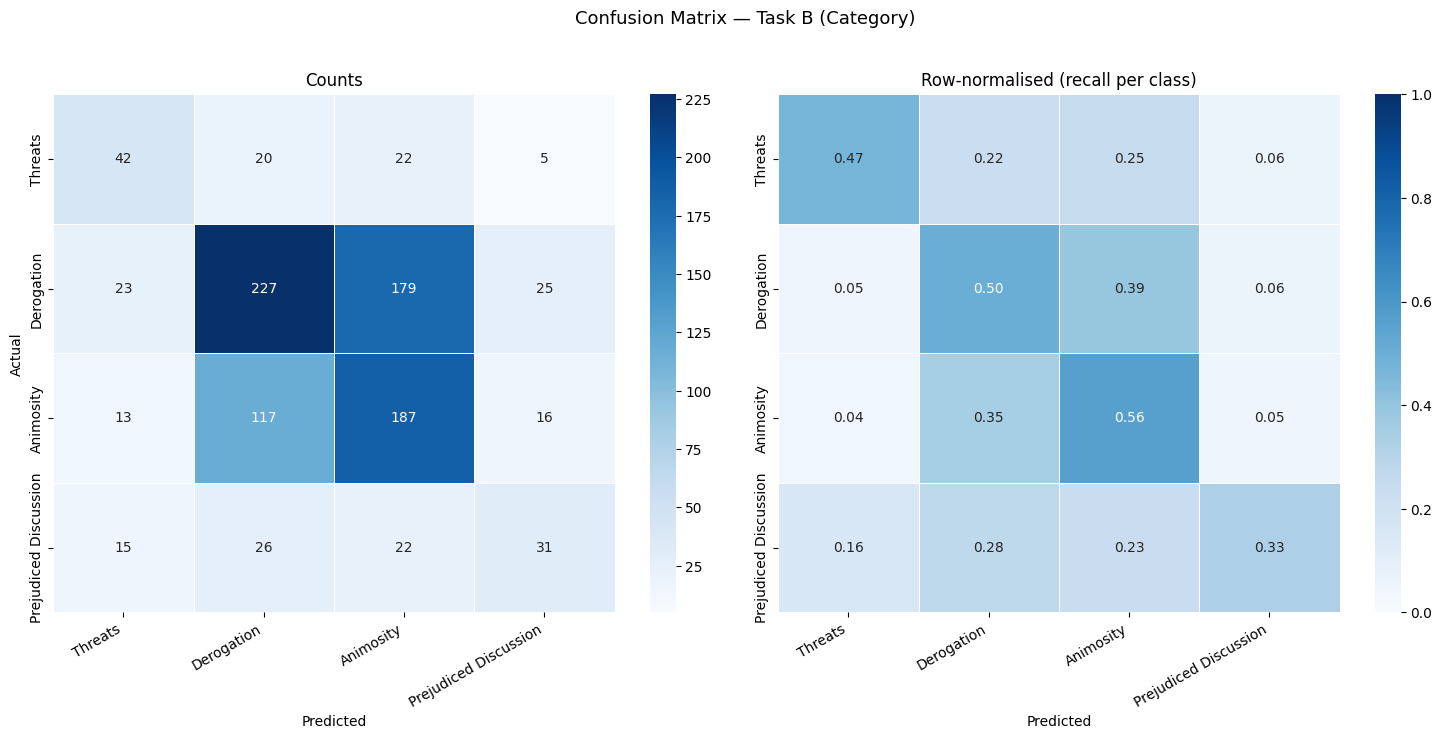

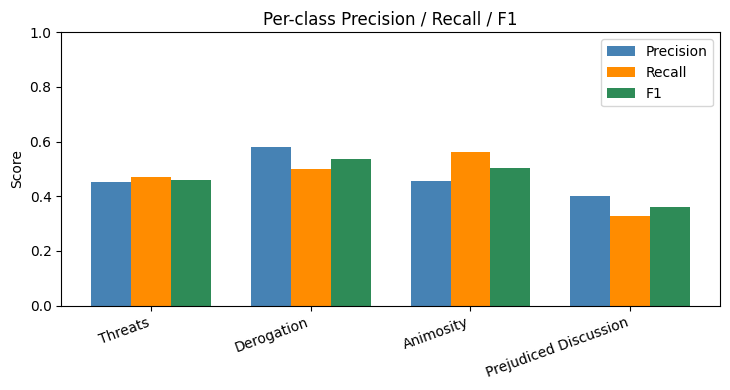


ERROR ANALYSIS

Total errors: 483 / 970 (49.8%)

Error rate per true class:


,class,errors,total,error_rate (%)
3,Prejudiced Discussion,63,94,67.0
0,Threats,47,89,52.8
1,Derogation,227,454,50.0
2,Animosity,146,333,43.8



Top confusion pairs (actual → predicted):


,actual,predicted,count
3,Derogation,Animosity,179
0,Animosity,Derogation,117
7,Prejudiced Discussion,Derogation,26
4,Derogation,Prejudiced Discussion,25
5,Derogation,Threats,23
6,Prejudiced Discussion,Animosity,22
9,Threats,Animosity,22
10,Threats,Derogation,20
1,Animosity,Prejudiced Discussion,16
8,Prejudiced Discussion,Threats,15


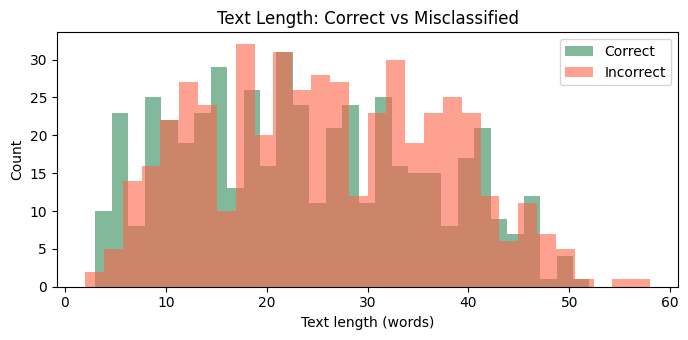


Sample misclassified examples:

  ✗ Actual: [Derogation]  →  Predicted: [Animosity]  (n = 179)
    • (0.83) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (0.74) she didn't have to be a bitch about it. she literally went out of her way to rub the rejection in his face, when a simpl
    • (0.50) i would pay to see her ass cracker. #nsfw

  ✗ Actual: [Animosity]  →  Predicted: [Derogation]  (n = 117)
    • (0.69) most here would fuck her.
    • (0.67) soy boys pms worse than women cause it's 24/7. they get their delicate feelings hurt because of lack of testosterone.it'
    • (0.68) #feminist looks to have sex with #nazis on #tinder. she even is a vegetarian, and an artist just like #hitler was! does 

  ✗ Actual: [Prejudiced Discussion]  →  Predicted: [Derogation]  (n = 26)
    • (0.79) yes, it is new. what remains constant is that feminists are playing to the fears of women to instill hate.
    • (0.76) th

In [3]:
rnn_category = run_rnn_category(state, device)


roberta-base — Task A (Binary)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


...

6      0.3535     0.9662    0.9538    0.8632    0.8210    LR: 1.69e-05


7      0.3293     0.9762    0.9677    0.8682    0.8221    LR: 1.60e-05


8      0.3168     0.9829    0.9767    0.8565    0.8126    LR: 1.51e-05


9      0.3134     0.9846    0.9790    0.8632    0.8187    LR: 1.42e-05


10     0.3010     0.9889    0.9849    0.8635    0.8197    LR: 1.33e-05

Early stopping triggered

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not sexist       0.92      0.90      0.91      3030
      Sexist       0.70      0.76      0.73       970

    accuracy                           0.86      4000
   macro avg       0.81      0.83      0.82      4000
weighted avg       0.87      0.86      0.87      4000

Accuracy : 0.8635
Macro F1 : 0.8197
Weighted F1 : 0.8655

Confusion Matrix (raw):
[[2713  317]
 [ 229  741]]


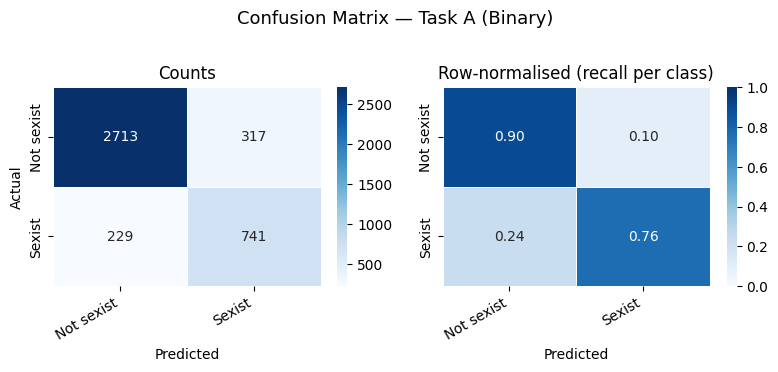

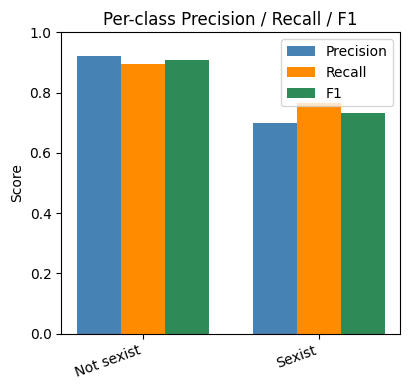


ERROR ANALYSIS

Total errors: 546 / 4000 (13.7%)

Error rate per true class:


,class,errors,total,error_rate (%)
1,Sexist,229,970,23.6
0,Not sexist,317,3030,10.5



Top confusion pairs (actual → predicted):


,actual,predicted,count
0,Not sexist,Sexist,317
1,Sexist,Not sexist,229


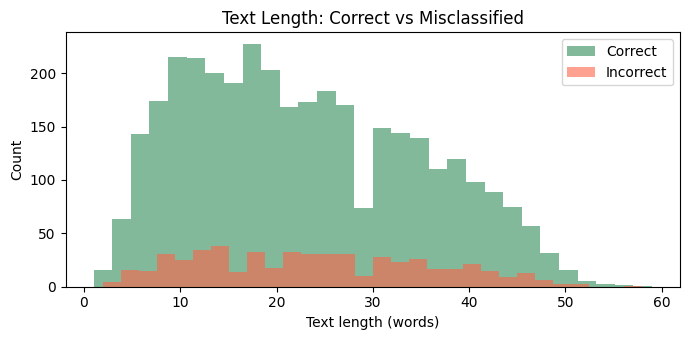


Sample misclassified examples:

  ✗ Actual: [Not sexist]  →  Predicted: [Sexist]  (n = 317)
    • (0.98) most men know instinctually the game. but their ego's are so fucking big that they think, not mine, not me. bang bang sh
    • (0.97) "when they go low.we beat women with flag poles and pepper spray them in the face." #miloatcal and antifa is a terrorist
    • (0.69) true, most do lol i get hit on by more fat girls than anything else. but they usually settle for an out of shape guy. fi

  ✗ Actual: [Sexist]  →  Predicted: [Not sexist]  (n = 229)
    • (0.87) i would pay to see her ass cracker. #nsfw
    • (0.87) 10/10 with interior decorating skills like yours, girls will be falling all over you. i'm falling for you a little mysel
    • (0.87) isn't it convenient that she doesn't have the video of this guy threatening to kill her! she films every moment of her l

Results logged → /content/drive/MyDrive/Explainable Detection of Online Sexism/results/results_binary.csv


In [4]:
tf_binary = run_transformer_binary(state, device)


roberta-base — Task B (Category)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  TrainLoss  TrainAcc  TrainF1   ValAcc    ValF1    
------------------------------------------------------------


1      1.4849     0.2598    0.2058    0.2113    0.2197    LR: 8.01e-06


...

13     0.5461     0.9882    0.9902    0.6361    0.6165    LR: 1.07e-05


14     0.5389     0.9941    0.9940    0.6464    0.6314    LR: 9.78e-06


15     0.5365     0.9941    0.9952    0.6289    0.6191    LR: 8.89e-06


16     0.5347     0.9938    0.9944    0.6361    0.6205    LR: 8.00e-06


17     0.5305     0.9967    0.9971    0.6351    0.6238    LR: 7.11e-06

Early stopping triggered

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

              Threats       0.65      0.76      0.70        89
           Derogation       0.69      0.63      0.66       454
            Animosity       0.57      0.65      0.61       333
Prejudiced Discussion       0.60      0.46      0.52        94

             accuracy                           0.64       970
            macro avg       0.63      0.63      0.62       970
         weighted avg       0.64      0.64      0.63       970

Accuracy : 0.6351
Macro F1 : 0.6238
Weighted F1 : 0.6343

Confusion Matrix (raw):
[[ 68   7  11   3]
 [ 22 288 128  16]
 [  8  98 217  10]
 [  6  23  22  43]]


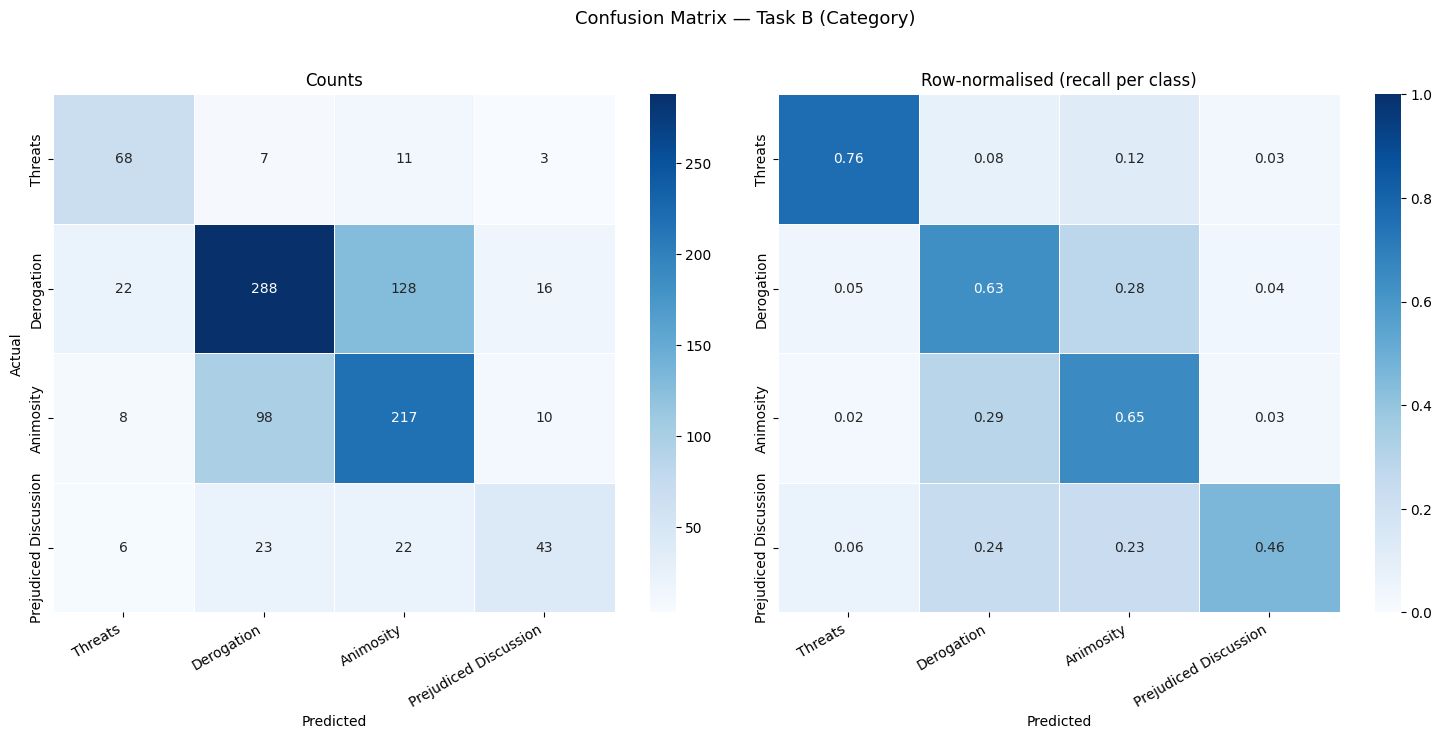

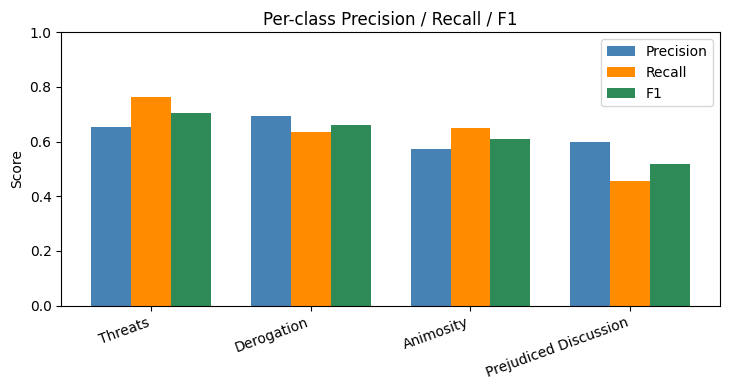


ERROR ANALYSIS

Total errors: 354 / 970 (36.5%)

Error rate per true class:


,class,errors,total,error_rate (%)
3,Prejudiced Discussion,51,94,54.3
1,Derogation,166,454,36.6
2,Animosity,116,333,34.8
0,Threats,21,89,23.6



Top confusion pairs (actual → predicted):


,actual,predicted,count
3,Derogation,Animosity,128
0,Animosity,Derogation,98
7,Prejudiced Discussion,Derogation,23
5,Derogation,Threats,22
6,Prejudiced Discussion,Animosity,22
4,Derogation,Prejudiced Discussion,16
9,Threats,Animosity,11
1,Animosity,Prejudiced Discussion,10
2,Animosity,Threats,8
10,Threats,Derogation,7


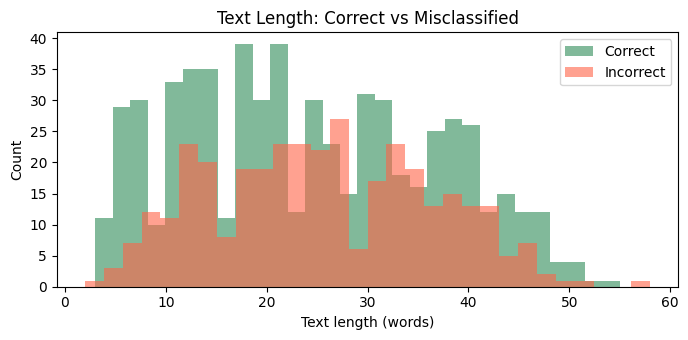


Sample misclassified examples:

  ✗ Actual: [Derogation]  →  Predicted: [Animosity]  (n = 128)
    • (0.84) yes, normal women want to be dominated. social scientists call it female hypergamy. and it is why women make bad bosses 
    • (0.82) imagine the woman you find most attractive in the world, she would let him fuck her in the ass on their first date. ther
    • (0.85) the view. empty head emotional woman's daily bitchcraft lesson.

  ✗ Actual: [Animosity]  →  Predicted: [Derogation]  (n = 98)
    • (0.42) typical praising of women and bashing of men. they're so predictable. and dumb.
    • (0.79) most here would fuck her.
    • (0.79) #feminist looks to have sex with #nazis on #tinder. she even is a vegetarian, and an artist just like #hitler was! does 

  ✗ Actual: [Prejudiced Discussion]  →  Predicted: [Derogation]  (n = 23)
    • (0.79) yes, it is new. what remains constant is that feminists are playing to the fears of women to instill hate.
    • (0.79) oh man i'm so sorry. y

In [5]:
tf_category = run_transformer_category(state, device)